# PEER+TEXT on held-out dataset E: peer agreement plus text checks for NL→FOL faithfulness

This notebook is a runnable walk-through of `method.py`, the end-to-end driver of the experiment. The experiment scores
**gold-free faithfulness metrics** for natural-language → first-order-logic (NL→FOL) formalisations: given a sentence
and a candidate FOL formula (and the other systems' formalisations of the same sentence), a metric returns a score for
how likely the candidate is to be **unfaithful** to the text. No gold formula is used at scoring time.

**The method (PEER+TEXT)**
- **PEER.** Graded cross-family consensus. The candidate is split into *claim units*. Each peer formalisation (from
  another model family) is aligned into the candidate's predicate vocabulary. Entailment is checked by a finite-model
  refuter first and z3 second. This gives:
  - `support`: the share of candidate claims the peers entail;
  - `coverage`: the share of the peers' majority claims the candidate entails;
  - `g_score = 1 − F1(support, coverage)`;
  - unit error codes: NEG / QUANT / SWAP / ADD / DROP.
- **TEXT.** The iteration-1 text checks:
  - `l2_bow`: content-word accounting between the sentence and the predicate names;
  - `l3_z3`: a small LLM answers a role questionnaire from the **text only**, and z3 answers the same questions exactly
    from the formula.
- **Fusion.** A logistic model over `[ALIGN:g_score, c_score_align, l2_bow, l3_z3]`. It was fitted on the iteration-1
  screen, frozen with a sha256 pre-registration, and then scored **once** on the 8,507 held-out rows of dataset E.

**What runs here.** The heavy stages (the solver-based scoring of 700 sentences, the LLM questionnaires and the judges)
take hours and need API keys and a GPU. This notebook loads a **100-row subset of dataset E together with its
pre-computed stage outputs**. It then runs the parts of the pipeline that work from those outputs:
1. the frozen PEER+TEXT fusion (`fused_score`, copied verbatim from `src/peer_text.py`), re-applied to each row's
   features;
2. the driver's `outputs` stage (`build_outputs()`, unchanged), which writes `method_out.json` in the
   `exp_gen_sol_out` schema;
3. a small AUROC evaluation of every metric against the gold-derived labels, compared with the full-E numbers.

The full results on dataset E (R_AB regime: 2,686 rows, 1,822 ERROR and 864 CORRECT): PEER+TEXT AUROC **0.790**,
c_score_align 0.782, TEXT alone 0.693, local Qwen3-8B judge 0.712.

## Setup
Install the packages the driver needs. `loguru` is not pre-installed on Colab. numpy, scikit-learn and matplotlib are pre-installed on Colab, so they are installed only when running locally, at Colab's exact versions.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# numpy, scikit-learn, matplotlib — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scikit-learn==1.6.1', 'matplotlib==3.10.0')

The original import block of `method.py` comes first. Below it are the extra imports for the fusion functions (`math`) and for the evaluation and plots.

In [2]:
from __future__ import annotations

import json
import subprocess
import sys
from pathlib import Path

from loguru import logger

# --- additional imports for the notebook (fusion re-derivation + evaluation/plots) ---
import math
from collections import Counter, defaultdict
import numpy as np
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

## Load the demo data
The data is fetched from GitHub. If that fails, the notebook falls back to a local `mini_demo_data.json`.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_qck1d05BqxkX/round-2/experiment-5/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print(f"{len(data['rows'])} rows; label mix:", Counter(r["label"]["final_label"] for r in data["rows"]))
print("frozen PEER variant:", data["prereg"]["variant"])

Dataset E (held-out NL->FOL candidates), 100-row demo subset for PEER+TEXT. Each row: per_item (all metric scores, label-free), blind (text + candidate FOL), label (final gold-derived label).
100 rows; label mix: Counter({'ERROR': 48, 'CORRECT': 45, 'UNPARSEABLE': 4, 'CONTESTED': 3})
frozen PEER variant: ALIGN


## Configuration
Every tunable knob is set here.
- `MAX_ROWS`: how many of the 100 demo rows go through the pipeline. The full experiment has 8,507 rows.
- `STAGE`: which stage of the driver to run. It replaces `sys.argv[1]`. The original default is `"all"`, which reruns
  `views`, `api`, `local`, `screen`, `score` and `analyse`. Those stages call `src/*.py` scripts that need the full
  workspace, API keys and a GPU. The demo runs only `"outputs"`, the stage that builds `method_out.json` from the stage
  results.
- `N_BOOT`: bootstrap resamples for the demo AUROC confidence intervals. The paper uses a sentence-cluster bootstrap
  with B=2000.

In [5]:
MAX_ROWS = 100         # demo rows to process (full dataset E: 8507)
STAGE = "outputs"       # original default: "all" (needs src/*.py, API keys, GPU)
N_BOOT = 2000           # sentence-cluster bootstrap resamples for the demo CIs (paper: 2000)
DEMO_ROOT = "demo_workspace"  # plays the role of the experiment workspace (ROOT in method.py)

## Workspace setup
In `method.py`, `ROOT` is the experiment directory. The driver reads these stage outputs from it:
- `results/per_item_E.jsonl`: every metric's score per row, label-free;
- `data/E_blind.jsonl`: the text and candidate FOL;
- `data/E_labels.jsonl`: the label view, joined only after the analysis;
- `results/analysis.json`, `results/prereg.json`, `results/prereg.sha256` and `results/p_tests.json`.

The only change here is that the notebook writes these files from the loaded `data` into `DEMO_ROOT`. That way the
original file-reading code runs unchanged. The logger setup and interpreter paths are copied as they are.

In [6]:
ROOT = Path(DEMO_ROOT).resolve()
PY = str(ROOT / ".venv" / "bin" / "python")
PY_GPU = str(ROOT / ".venv_gpu" / "bin" / "python")

# --- notebook-only: materialise the demo subset as the workspace files method.py reads ---
_rows = data["rows"][:MAX_ROWS]
(ROOT / "results").mkdir(parents=True, exist_ok=True)
(ROOT / "data").mkdir(parents=True, exist_ok=True)
(ROOT / "results" / "per_item_E.jsonl").write_text("".join(json.dumps(r["per_item"], ensure_ascii=False) + "\n" for r in _rows))
(ROOT / "data" / "E_blind.jsonl").write_text("".join(json.dumps(r["blind"], ensure_ascii=False) + "\n" for r in _rows))
(ROOT / "data" / "E_labels.jsonl").write_text("".join(json.dumps(r["label"], ensure_ascii=False) + "\n" for r in _rows))
(ROOT / "results" / "analysis.json").write_text(json.dumps(data["analysis"]))
(ROOT / "results" / "prereg.json").write_text(json.dumps(data["prereg"]))
(ROOT / "results" / "prereg.sha256").write_text(data["prereg_sha256_line"])
(ROOT / "results" / "p_tests.json").write_text(json.dumps(data["p_tests"]))
print(f"workspace ./{DEMO_ROOT}: {len(_rows)} rows written")

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(ROOT / "logs" / "method.log", rotation="30 MB", level="DEBUG");

workspace ./demo_workspace: 100 rows written


## Driver helpers (unchanged)
- `sh()` runs one pipeline stage as a subprocess and fails loudly.
- `jl()` reads a JSONL file.
- `s()` turns a score into the string form the `exp_gen_sol_out` schema expects: 6 decimals, or `"NA"` when the score
  is missing.

In [7]:
def sh(args: list[str]) -> None:
    logger.info("$ " + " ".join(args))
    r = subprocess.run(args, cwd=ROOT)
    if r.returncode != 0:
        raise RuntimeError(f"stage failed ({r.returncode}): {' '.join(args)}")


def jl(p: Path) -> list[dict]:
    return [json.loads(l) for l in p.read_text().splitlines() if l.strip()] if p.exists() else []


def s(x) -> str:
    if x is None:
        return "NA"
    if isinstance(x, float):
        return f"{x:.6f}"
    return str(x)

## The frozen PEER+TEXT fusion (from `src/peer_text.py`, verbatim)
The `score` stage (`src/score_E.py assemble`) turns each row's features into the final score with `fused_score()`.
Each feature is z-standardised with the screen mean and SD. A missing feature gets z = 0.

The frozen logistic is then applied:
- the main model uses `ALIGN:g_score`, `c_score_align`, `l2_bow` and `l3_z3`;
- when no peer is available, the pre-registered **TEXT-only** model (`l2_bow`, `l3_z3`) is used instead;
- an unparseable candidate gets `p_error = 1.0`, the most suspicious score.

`fired_signal` names the side (PEER or TEXT) that contributes most to the score.

In [8]:
def _z(x, mu, sd):
    return 0.0 if x is None else (x - mu) / (sd if sd > 0 else 1.0)


def apply_logistic(model: dict, feats: dict) -> float:
    """model = {'features', 'mean', 'sd', 'coef', 'intercept'}; missing feature -> z = 0."""
    s = model["intercept"]
    for f, m, sd, c in zip(model["features"], model["mean"], model["sd"], model["coef"]):
        s += c * _z(feats.get(f), m, sd)
    return 1 / (1 + math.exp(-s))


def fused_score(frozen: dict, feats: dict) -> dict:
    """Frozen PEER+TEXT fusion. Unparseable -> p_error 1.0. peer_unavailable -> frozen TEXT-only model (pre-registered).
    fired_signal = argmax standardized contribution (PEER = g/c_score_nf features, TEXT = l2_bow/l3)."""
    if feats.get("coverage_status") == "UNPARSEABLE":
        return {"p_error": 1.0, "flag": 1, "fired_signal": "UNPARSEABLE", "model_used": "none"}
    main = frozen["fusion"]
    use = main
    if feats.get("peer_unavailable") or feats.get(main["features"][0]) is None:
        use = frozen["text_only"]
    p = apply_logistic(use, feats)
    contrib = {f: c * _z(feats.get(f), m, sd) for f, m, sd, c in zip(use["features"], use["mean"], use["sd"], use["coef"])}
    top = max(contrib, key=contrib.get) if contrib else None
    sig = "PEER" if top in ("g_score", "c_score_nf", "c_score_align") else ("TEXT" if top else None)
    thr = main["threshold"] if use is main else frozen["text_only"]["threshold"]
    return {"p_error": p, "flag": int(p >= thr), "fired_signal": sig, "model_used": "fusion" if use is main else "text_only"}

The next cell checks the frozen fusion. It rebuilds each row's feature dict the way `score_E.py assemble` does. In the
per-sentence scorer output the peer features carry the variant prefix (`ALIGN:g_score`); in `per_item_E.jsonl` they are
stored as `g_score`. It then recomputes `p_peer_text` and compares it with the stored value. The frozen coefficients are
printed too. `l2_bow` and `c_score_align` carry the largest weights.

In [9]:
frozen = data["prereg"]["frozen"]
fz = frozen["fusion"]
print("frozen fusion  (screen OOF AUROC %.3f, threshold %.3f)" % (fz["oof_auroc"], fz["threshold"]))
for f, c in zip(fz["features"], fz["coef"]):
    print(f"  {f:<16} coef {c:+.3f}")

max_abs_diff, n_checked, fired = 0.0, 0, Counter()
for r in jl(ROOT / "results" / "per_item_E.jsonl"):
    feats = {"coverage_status": r["coverage_status"], "peer_unavailable": r["peer_unavailable"],
             f"{frozen['variant']}:g_score": r["g_score"], "c_score_align": r["c_score_align"],
             "l2_bow": r["l2_bow"], "l3_z3": r["l3_z3"]}
    fs = fused_score(frozen, feats)
    max_abs_diff = max(max_abs_diff, abs(fs["p_error"] - r["p_peer_text"]))
    n_checked += 1
    fired[fs["fired_signal"]] += 1
print(f"re-derived p_peer_text for {n_checked} rows; max |recomputed - stored| = {max_abs_diff:.2e}")
print("fired_signal counts:", dict(fired))

frozen fusion  (screen OOF AUROC 0.943, threshold 0.690)
  ALIGN:g_score    coef -0.116
  c_score_align    coef +1.746
  l2_bow           coef +3.087
  l3_z3            coef +0.845
re-derived p_peer_text for 100 rows; max |recomputed - stored| = 0.00e+00
fired_signal counts: {'UNPARSEABLE': 4, 'TEXT': 38, 'PEER': 58}


## `build_outputs()`: the driver's `outputs` stage (unchanged)
This stage joins, for each row of dataset E:
- the blind input (text, candidate FOL, system, prompt variant);
- every metric's score, as `predict_*`, oriented so that **higher = more likely an error**;
- the final gold-derived label, joined only **after** the analysis.

It writes these into `method_out.json` in the `exp_gen_sol_out` schema, together with the pre-registration hash and the
headline AUROC tables.

In [10]:
def build_outputs() -> None:
    """method_out.json in the exp_gen_sol_out schema: one example per E row (input = blind-view JSON, output = the E
    final label joined AFTER the analysis), predict_* = every metric's score (higher = more likely an error)."""
    items = jl(ROOT / "results" / "per_item_E.jsonl")
    labels = {r["row_key"]: r for r in jl(ROOT / "data" / "E_labels.jsonl")}
    blind = {r["row_key"]: r for r in jl(ROOT / "data" / "E_blind.jsonl")}
    analysis = json.loads((ROOT / "results" / "analysis.json").read_text())
    pre = json.loads((ROOT / "results" / "prereg.json").read_text())
    ex = []
    for r in items:
        b = blind[r["row_key"]]
        L = labels[r["row_key"]]
        inp = {"text": b["text"], "candidate_fol": b["candidate_fol"], "system": b["system"], "prompt_variant": b["prompt_variant"],
               "row_key": r["row_key"], "item_id": b["item_id"], "sentence_id": b["sentence_id"]}
        e = {"input": json.dumps(inp, ensure_ascii=False), "output": L["final_label"],
             "predict_peer_text": s(r.get("p_peer_text")), "predict_peer_text_flag": s(r.get("flag")),
             "predict_peer": s(r.get("peer_only")), "predict_text": s(r.get("p_text")),
             "predict_g_score": s(r.get("g_score")), "predict_c_score_nf": s(r.get("c_score_nf")),
             "predict_c_score_align": s(r.get("c_score_align")), "predict_nf_g_score": s(r.get("nf_g_score")),
             "predict_nf_c_score": s(r.get("nf_c_score")), "predict_l2_bow": s(r.get("l2_bow")), "predict_l3": s(r.get("l3_z3")),
             "predict_l1_any": s(r.get("l1_any")), "predict_l2_role": s(r.get("l2_role")),
             "predict_judge_cheap_disg": s(r.get("judge_cheap_disg")), "predict_judge_cheap_orig": s(r.get("judge_cheap_orig")),
             "predict_judge_local_qwen8b_disg": s(r.get("judge_local_qwen8b_disg")),
             "predict_judge_local_qwen8b_orig": s(r.get("judge_local_qwen8b_orig")),
             "metadata_row_key": r["row_key"], "metadata_item_id": r["item_id"], "metadata_sentence_id": r["sentence_id"],
             "metadata_system": r["system"], "metadata_system_class": r["system_class"], "metadata_family_vendor": r["family_vendor"],
             "metadata_stratum": r["stratum"], "metadata_strata": r["strata"], "metadata_fold_E": r["fold_E"],
             "metadata_label_tier": L["label_tier"], "metadata_repair_ops": L["repair_ops"], "metadata_error_ops": L["error_ops"],
             "metadata_reading_choice": L["reading_choice"], "metadata_coverage_status": r["coverage_status"],
             "metadata_unit_codes": [c["code"] + ":" + c.get("unit", "")[:120] for c in (r.get("unit_codes") or [])][:12],
             "metadata_top_code": r.get("top_code"), "metadata_fired_signal": r.get("fired_signal"),
             "metadata_model_used": r.get("model_used"), "metadata_n_unknown": r.get("n_unknown"),
             "metadata_n_peers_used": r.get("n_peers_used"), "metadata_peer_unavailable": r.get("peer_unavailable"),
             "metadata_support": r.get("support"), "metadata_coverage": r.get("coverage"),
             "metadata_medoid_ops": r.get("medoid_ops"), "metadata_judge_local_type": r.get("judge_local_qwen8b_disg_type"),
             "metadata_cost_usd": (r.get("cost_usd_peer_text") or 0.0), "metadata_judge_cost_usd": r.get("judge_cost_usd"),
             "metadata_secs": (r.get("secs_pairs") or 0.0) + (r.get("secs_text") or 0.0),
             "metadata_prereg_sha256": r["prereg_sha256"]}
        ex.append(e)
    heads = {k: {kk: vv for kk, vv in v.items() if kk in ("n", "n_error", "n_correct", "metrics")} for k, v in analysis["a_tables"].items()}
    out = {"metadata": {
        "method_name": "PEER+TEXT (graded cross-family consensus fused with solver-exact text checks), frozen on the screen, scored once on E",
        "prereg_sha256": (ROOT / "results" / "prereg.sha256").read_text().split()[0],
        "peer_variant": pre["variant"], "F1_failed_on_screen": pre["selection_evidence"]["F1_failed"],
        "fusion": pre["frozen"]["fusion"], "text_only": pre["frozen"]["text_only"],
        "orientation": "every predict_* is oriented so that higher = more likely an error; NA = not available",
        "headline_auroc_tables": heads, "criteria": analysis["criteria"],
        "p_tests": json.loads((ROOT / "results" / "p_tests.json").read_text()),
        "workspace": str(ROOT)},
        "datasets": [{"dataset": "E_heldout_candidates", "examples": ex}]}
    (ROOT / "method_out.json").write_text(json.dumps(out, ensure_ascii=False))
    logger.info(f"method_out.json: {len(ex)} examples, {(ROOT / 'method_out.json').stat().st_size / 1e6:.1f} MB")

## `main()`: the stage dispatcher
This is the original dispatcher. The only change is that `stage` comes from the `STAGE` config variable, because a
notebook has no command-line arguments. With `STAGE = "outputs"`, only `build_outputs()` runs. The other branches show
how the full pipeline chains its stages:
1. data views;
2. the API calls (L3 questionnaires and the flash-lite judges);
3. the local Qwen3-8B judge;
4. the screen fit and pre-registration freeze;
5. the one-shot scoring of E;
6. the analysis, which is the only step that joins labels.

In [11]:
@logger.catch(reraise=True)
def main():
    stage = STAGE  # original: sys.argv[1] if len(sys.argv) > 1 else "all"
    if stage in ("views", "all"):
        sh([PY, "src/data_views.py"])
    if stage in ("api", "all"):
        sh([PY, "src/run_api_E.py"])
    if stage in ("local", "all") and Path(PY_GPU).exists():
        sh([PY_GPU, "src/local_judge_E.py"])
    if stage in ("screen", "all"):
        if not (ROOT / "results" / "prereg.json").exists():
            sh([PY, "src/screen_fit.py", "compute"])
            sh([PY, "src/screen_fit.py", "fit"])
            sh([PY, "src/screen_fit.py", "freeze"])
    if stage in ("score", "all"):
        for st in ("mini", "100", "all"):
            sh([PY, "src/score_E.py", "run", "--stage", st])
        sh([PY, "src/score_E.py", "assemble"])
    if stage in ("analyse", "all"):
        sh([PY, "src/analyse_E.py"])
    if stage in ("outputs", "all"):
        build_outputs()


main()

12:40:16|INFO   |method_out.json: 100 examples, 0.3 MB


## Results: metric AUROC against the gold-derived labels
This reads `method_out.json` back and applies the primary label regime **R_AB**, using the `regime()` rule from
`src/analyse_E.py`. R_AB keeps LLM rows only, label tiers A and B, and decided labels (ERROR = 1, CORRECT = 0). It drops
CONTESTED, UNPARSEABLE, reading-choice rows and gold-as-system rows.

For each metric the cell then computes:
- AUROC on the demo rows, with a sentence-cluster bootstrap CI;
- the pooled R_AB AUROC on the full 2,686-row set, taken from `analysis.json`, for comparison.

The demo subset is small (88 R_AB rows) and was sampled with equal counts per (stratum × label) cell, so its CIs are
wide. The equal counts also remove the length/stratum composition effect that inflates the pooled full-E AUROC (the
within-stratum placebo on E is 0.59, not 0.50). Demo AUROCs are therefore closer to the paper's **stratified** figures
(PEER+TEXT 0.753, c_score_align 0.741, TEXT 0.670, local judge 0.677) than to the pooled ones shown in the last column.

In [12]:
out = json.loads((ROOT / "method_out.json").read_text())
exs = out["datasets"][0]["examples"]
lab = {r["label"]["row_key"]: r["label"] for r in data["rows"]}

def regime_AB(e):
    L = lab[e["metadata_row_key"]]
    if L["system_class"] != "llm" or L.get("reading_choice"):
        return None
    if L["final_label"] not in ("CORRECT", "ERROR") or L["label_tier"] not in ("A", "B"):
        return None
    return 1 if L["final_label"] == "ERROR" else 0

rab = [(e, regime_AB(e)) for e in exs]
rab = [(e, y) for e, y in rab if y is not None]
print(f"method_out.json: {len(exs)} examples; R_AB rows: {len(rab)} "
      f"(ERROR {sum(y for _, y in rab)}, CORRECT {sum(1 - y for _, y in rab)})")

# predict_* column -> analysis.json metric key (full-E reported AUROC)
METRICS = [("predict_peer_text", "p_peer_text", "PEER+TEXT (ours)"), ("predict_c_score_align", "c_score_align", "c_score_align"),
           ("predict_peer", "peer_only", "PEER alone (g_score)"), ("predict_nf_c_score", "nf_c_score", "NF-anchored c_score"),
           ("predict_text", "p_text", "TEXT alone"), ("predict_l2_bow", "l2_bow", "L2-bow"), ("predict_l3", "l3_z3", "L3"),
           ("predict_l1_any", "l1_any", "L1 lint (any)"), ("predict_judge_local_qwen8b_disg", None, "local judge Qwen3-8B (disg)")]
full = out["metadata"]["headline_auroc_tables"]["R_AB pooled"]["metrics"]
full_judge = data["analysis"]["criteria"]["judge_local_qwen8b_disg"]["delta_R_AB"]

rng = np.random.default_rng(0)
def auroc_ci(col):
    pairs = [(float(e[col]), y, e["metadata_sentence_id"]) for e, y in rab if e[col] != "NA"]
    if len({y for _, y, _ in pairs}) < 2:
        return None, (None, None), len(pairs)
    x = np.array([p[0] for p in pairs]); yy = np.array([p[1] for p in pairs]); sid = [p[2] for p in pairs]
    auc = roc_auc_score(yy, x)
    groups = defaultdict(list)
    for i, g in enumerate(sid):
        groups[g].append(i)
    keys = list(groups); boots = []
    for _ in range(N_BOOT):
        idx = [i for k in rng.choice(len(keys), len(keys)) for i in groups[keys[k]]]
        if len(set(yy[idx])) == 2:
            boots.append(roc_auc_score(yy[idx], x[idx]))
    return auc, tuple(np.percentile(boots, [2.5, 97.5])), len(pairs)

rows_tab = []
print(f"\n{'metric':<30}{'n':>5}{'demo AUROC':>12}{'demo 95% CI':>18}{'full-E AUROC':>14}")
for col, key, name in METRICS:
    auc, ci, n = auroc_ci(col)
    fe = full[key]["auroc"] if key else data["judge_local_full_R_AB"]["auroc"]
    rows_tab.append((name, auc, ci, fe))
    ci_s = f"[{ci[0]:.2f}, {ci[1]:.2f}]" if ci[0] is not None else "-"
    print(f"{name:<30}{n:>5}{(auc if auc is not None else float('nan')):>12.3f}{ci_s:>18}"
          f"{fe:>14.3f}")
print("local judge full-E AUROC is on the rows where the judge scored; delta PEER+TEXT - judge on full E = "
      f"{full_judge['delta']:+.3f} [{full_judge['ci'][0]:.3f}, {full_judge['ci'][1]:.3f}]")
print("\npre-registered prediction verdicts:", {k: v for k, v in out["metadata"]["p_tests"].items() if k != "criteria"})

method_out.json: 100 examples; R_AB rows: 88 (ERROR 44, CORRECT 44)

metric                            n  demo AUROC       demo 95% CI  full-E AUROC


PEER+TEXT (ours)                 88       0.688      [0.57, 0.80]         0.790


c_score_align                    88       0.703      [0.58, 0.82]         0.782


PEER alone (g_score)             88       0.700      [0.57, 0.82]         0.748


NF-anchored c_score              88       0.675      [0.54, 0.79]         0.743


TEXT alone                       88       0.634      [0.53, 0.74]         0.693


L2-bow                           88       0.676      [0.57, 0.78]         0.734


L3                               88       0.536      [0.42, 0.64]         0.579


L1 lint (any)                    88       0.523      [0.50, 0.56]         0.546


local judge Qwen3-8B (disg)      88       0.728      [0.61, 0.83]         0.712
local judge full-E AUROC is on the rows where the judge scored; delta PEER+TEXT - judge on full E = +0.078 [0.043, 0.112]

pre-registered prediction verdicts: {'P1_R_AB': 'INCONCLUSIVE', 'P1_R_A': 'INCONCLUSIVE', 'P2': 'REFUTED', 'P3': 'INCONCLUSIVE', 'P4': 'REFUTED'}


### Visualisation
**Left:** AUROC per metric, on the demo subset (with bootstrap CI) and on the full dataset E. **Right:** distribution of the fused PEER+TEXT score for ERROR vs CORRECT rows, with the frozen flag threshold.

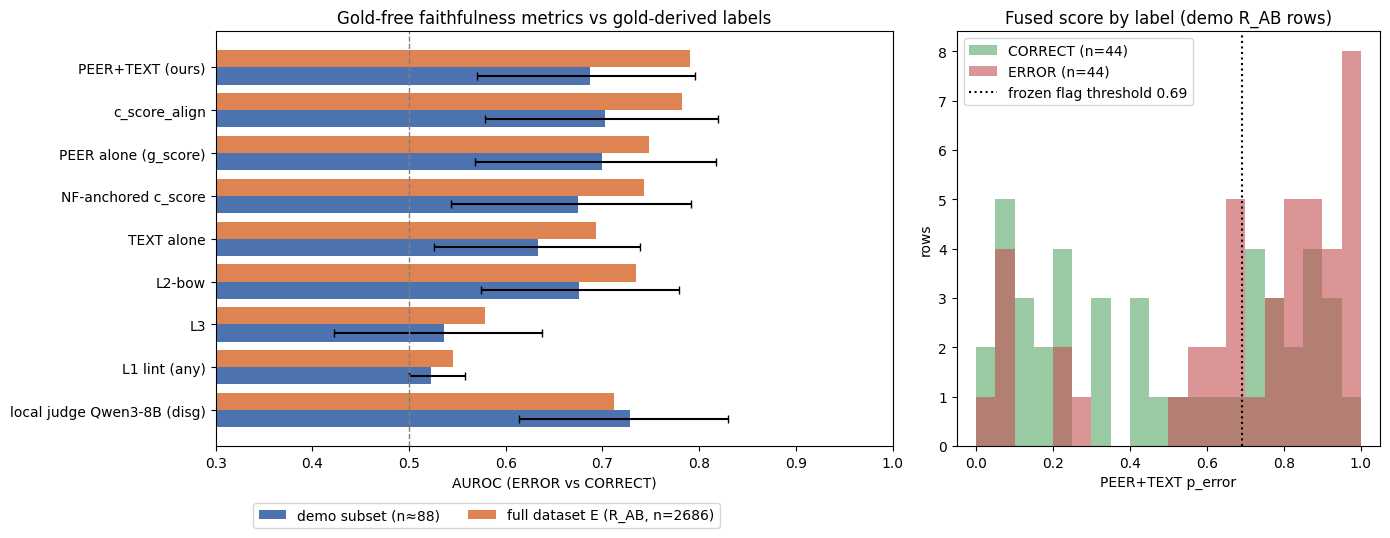

In [13]:
names = [r[0] for r in rows_tab]
demo = [r[1] if r[1] is not None else np.nan for r in rows_tab]
lo = [r[1] - r[2][0] if r[2][0] is not None else 0 for r in rows_tab]
hi = [r[2][1] - r[1] if r[2][0] is not None else 0 for r in rows_tab]
fullv = [r[3] for r in rows_tab]

fig, ax = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={"width_ratios": [1.6, 1]})
yp = np.arange(len(names))
ax[0].barh(yp + 0.2, demo, 0.4, xerr=[lo, hi], color="#4C72B0", label=f"demo subset (n≈{len(rab)})", capsize=3)
ax[0].barh(yp - 0.2, fullv, 0.4, color="#DD8452", label="full dataset E (R_AB, n=2686)")
ax[0].axvline(0.5, color="grey", ls="--", lw=1)
ax[0].set_yticks(yp); ax[0].set_yticklabels(names); ax[0].invert_yaxis()
ax[0].set_xlim(0.3, 1.0); ax[0].set_xlabel("AUROC (ERROR vs CORRECT)")
ax[0].set_title("Gold-free faithfulness metrics vs gold-derived labels"); ax[0].legend(loc="upper center", bbox_to_anchor=(0.4, -0.12), ncol=2)

pe = [float(e["predict_peer_text"]) for e, y in rab if y == 1]
pc = [float(e["predict_peer_text"]) for e, y in rab if y == 0]
bins = np.linspace(0, 1, 21)
ax[1].hist(pc, bins=bins, alpha=0.6, label=f"CORRECT (n={len(pc)})", color="#55A868")
ax[1].hist(pe, bins=bins, alpha=0.6, label=f"ERROR (n={len(pe)})", color="#C44E52")
ax[1].axvline(frozen["fusion"]["threshold"], color="k", ls=":", label=f"frozen flag threshold {frozen['fusion']['threshold']:.2f}")
ax[1].set_xlabel("PEER+TEXT p_error"); ax[1].set_ylabel("rows"); ax[1].set_title("Fused score by label (demo R_AB rows)")
ax[1].legend()
plt.tight_layout(); plt.show()

### Example rows
Some ERROR rows with the highest PEER+TEXT scores. For each one the cell shows the unit error codes PEER assigned (NEG / QUANT / SWAP / ADD for unsupported claims, DROP for uncovered majority claims) and the repair operations of the gold label.

In [14]:
top = sorted([(float(e["predict_peer_text"]), e) for e, y in rab if y == 1], key=lambda t: -t[0])[:4]
for p, e in top:
    inp = json.loads(e["input"])
    print(f"p_error={p:.3f}  fired={e['metadata_fired_signal']}  system={inp['system']}  stratum={e['metadata_stratum']}")
    print("  TEXT :", inp["text"][:200])
    print("  FOL  :", inp["candidate_fol"][:200])
    print("  unit codes:", [c.split(":")[0] for c in e["metadata_unit_codes"]], "| gold repair ops:", e["metadata_repair_ops"])
    print()

p_error=1.000  fired=TEXT  system=G1b:meta-llama/llama-3.3-70b-instruct  stratum=CTRL
  TEXT : Boston Celtics are a team that lost the NBA finals.
  FOL  : ∃x (Team(x) ∧ Name(x, bostonCeltics) ∧ LostNBAFinals(x))
  unit codes: ['ADD', 'DROP', 'DROP', 'DROP'] | gold repair ops: None

p_error=1.000  fired=TEXT  system=G7:openai/gpt-4.1-mini  stratum=CTRL
  TEXT : None of the employees in James's town who work for this company are from China.
  FOL  : ¬∃x (Employee(x) ∧ LivesIn(x, jamesTown) ∧ WorksFor(x, thisCompany) ∧ From(x, china))
  unit codes: ['ADD', 'DROP', 'DROP', 'DROP'] | gold repair ops: None

p_error=0.995  fired=PEER  system=G3:mistralai/mistral-small-3.2-24b-instruct  stratum=L25
  TEXT : A type of machine that is used to convert one form of energy into another, such as an electric motor that converts electrical energy into mechanical energy, is a converter.
  FOL  : ∀x (Machine(x) ∧ ∃y ∃z (FormOf(y, energy) ∧ FormOf(z, energy) ∧ Converts(x, y, z)) → Converter(x))
  unit co